In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski 
from pathlib import Path
from scipy.stats import linregress

def s_topple_once(grid, mask):
    """
    Cells with value >= 2 lose 2 and give +1 to two random N,S,E,W neighbours.
    We delete grains leaving the boundary are deleted.
    """
    grid = np.asarray(grid)
    H, W = grid.shape
    m = mask.astype(bool)

    #subtract 2 at all active sites
    out = grid.copy()
    out[m] -= 2

    #make boundingbox
    bb = np.zeros((H+2, W+2), dtype=grid.dtype)
    bb[1:-1, 1:-1] = out

    xs, ys = np.where(m)
    xs = xs + 1
    ys = ys + 1
    n = xs.size

    deltas = np.array([[-1,0],[1,0],[0,-1],[0,1]], dtype=int)
    dirs = np.random.randint(0, 4, size=(n, 2))

    #first grain
    d0 = deltas[dirs[:, 0]]
    tx0 = xs + d0[:, 0]
    ty0 = ys + d0[:, 1]
    np.add.at(bb, (tx0, ty0), 1)

    #second grain
    d1 = deltas[dirs[:, 1]]
    tx1 = xs + d1[:, 0]
    ty1 = ys + d1[:, 1]
    np.add.at(bb, (tx1, ty1), 1)

    #remove bb
    out = bb[1:-1, 1:-1]
    new_mask = (out >= 2)
    topples = n
    return out, new_mask, topples

def SOC(n, N):
    """
    Run SOC simulation for n timesteps for lattice size N.
    """
    sandbox = np.random.randint(0,2,size=(N,N))
    #sandbox = np.zeros((N,N))
    count = np.zeros(n)
    grid_height = np.zeros(n)
    L = np.zeros(n)


    for _ in range(n):
        #Simulation time estimate
        if _%round(n/4) == 0:
            print(f"{_/n}% Done")

        i,j = np.random.randint(0,N, size = 2)
        min_x = i
        max_x = i
        min_y = j
        max_y = j

        sandbox[i,j] += 1
        mask = sandbox >= 2
        while mask.any():
            #sites that will topple this iteration
            xs, ys = np.where(mask)

            if xs.size:
                #update total span
                min_x = min(min_x, int(xs.min()))
                max_x = max(max_x, int(xs.max()))
                min_y = min(min_y, int(ys.min()))
                max_y = max(max_y, int(ys.max()))

            sandbox, mask, topples = s_topple_once(sandbox, mask)
            count[_] += topples
        
        #calculate longest linear span
        L_x = max_x-min_x+1
        L_y = max_y-min_y+1
        L[_] = max(L_x, L_y)
        grid_height[_] = np.mean(sandbox)
    return count, grid_height, L


In [5]:
grids25, aval_L25, grid_height25, L_25 = SOC(1000000,25)

0.0% Done
0.25% Done
0.5% Done
0.75% Done


KeyboardInterrupt: 

In [7]:
'''
aval_L25, grid_height25, L_25 = SOC(100000,25)
aval_L50, grid_height50, L_50 = SOC(100000,50)
aval_L100, grid_height100, L_100 = SOC(100000, 100)
aval_L200, grid_height200, L_200 = SOC(100000,200)

'''
# output directory
outdir = Path("soc_data")
outdir.mkdir(exist_ok=True)
# --- Save everything ---
np.save(outdir / "2aval_L25.npy", aval_L25)
np.save(outdir / "2grid_height25.npy", grid_height25)
np.save(outdir / "2L_25.npy", np.array(L_25))

np.save(outdir / "2aval_L50.npy", aval_L50)
np.save(outdir / "2grid_height50.npy", grid_height50)
np.save(outdir / "2L_50.npy", np.array(L_50))

np.save(outdir / "2aval_L100.npy", aval_L100)
np.save(outdir / "2grid_height100.npy", grid_height100)
np.save(outdir / "2L_100.npy", np.array(L_100))

np.save(outdir / "2aval_L200.npy", aval_L200)
np.save(outdir / "2grid_height200.npy", grid_height200)
np.save(outdir / "2L_200.npy", np.array(L_200))

print(f"✅ All simulation data saved to: {outdir.resolve()}")



✅ All simulation data saved to: C:\Users\lucq0\Desktop\ComplexPhysics\src\soc_data


In [15]:
# Directory containing saved data
outdir = Path("soc_data")

# --- Load everything ---
aval_L25 = np.load(outdir / "aval_L25.npy", allow_pickle=True)
grid_height25 = np.load(outdir / "grid_height25.npy", allow_pickle=True)
L_25 = np.load(outdir / "L_25.npy", allow_pickle=True)

aval_L50 = np.load(outdir / "aval_L50.npy", allow_pickle=True)
grid_height50 = np.load(outdir / "grid_height50.npy", allow_pickle=True)
L_50 = np.load(outdir / "L_50.npy", allow_pickle=True)

aval_L100 = np.load(outdir / "aval_L100.npy", allow_pickle=True)
grid_height100 = np.load(outdir / "grid_height100.npy", allow_pickle=True)
L_100 = np.load(outdir / "L_100.npy", allow_pickle=True)

aval_L200 = np.load(outdir / "aval_L200.npy", allow_pickle=True)
grid_height200 = np.load(outdir / "grid_height200.npy", allow_pickle=True)
L_200 = np.load(outdir / "L_200.npy", allow_pickle=True)

print("✅ All simulation data loaded successfully!")

✅ All simulation data loaded successfully!


Text(0, 0.5, '(C) Mean lattice height | $\\overline{h}$')

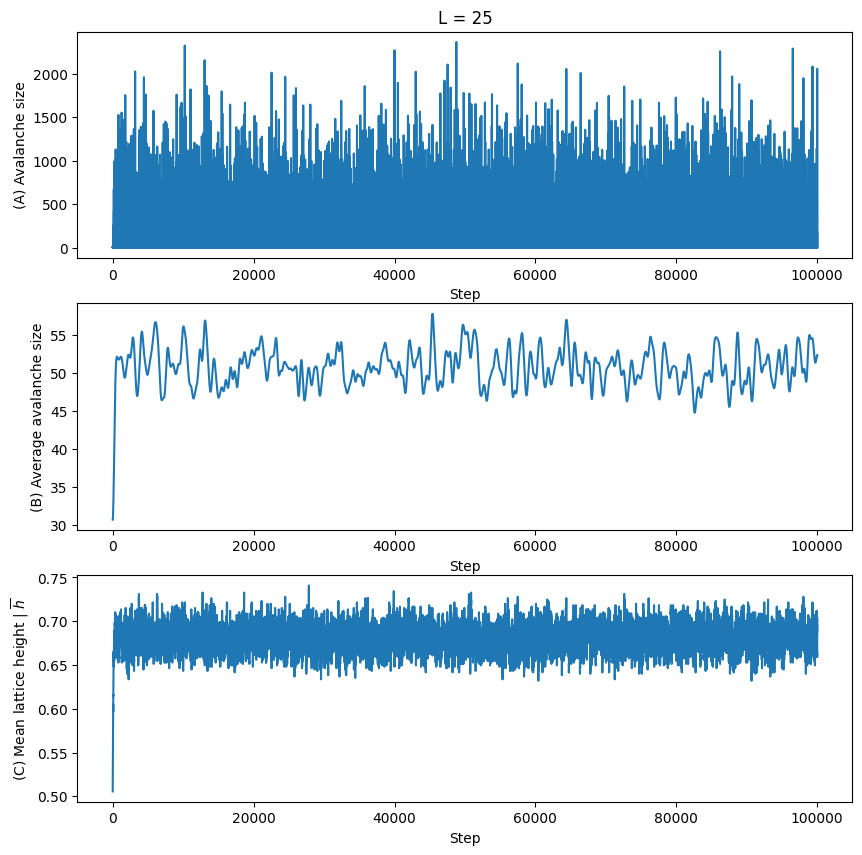

In [8]:
plt.figure(figsize=(10, 10))

plt.subplot(3, 1, 1)
plt.plot(aval_L25)
plt.title("L = 25")
plt.xlabel("Step")
plt.ylabel("(A) Avalanche size")

plt.subplot(3, 1, 2)
mean_aval25 = ski.filters.gaussian(aval_L25, sigma = (200), mode='reflect')
plt.plot(mean_aval25)
plt.xlabel("Step")
plt.ylabel("(B) Average avalanche size")

plt.subplot(3, 1, 3)
plt.plot(grid_height25)
plt.xlabel("Step")
plt.ylabel(r"(C) Mean lattice height | $\overline{h}$")


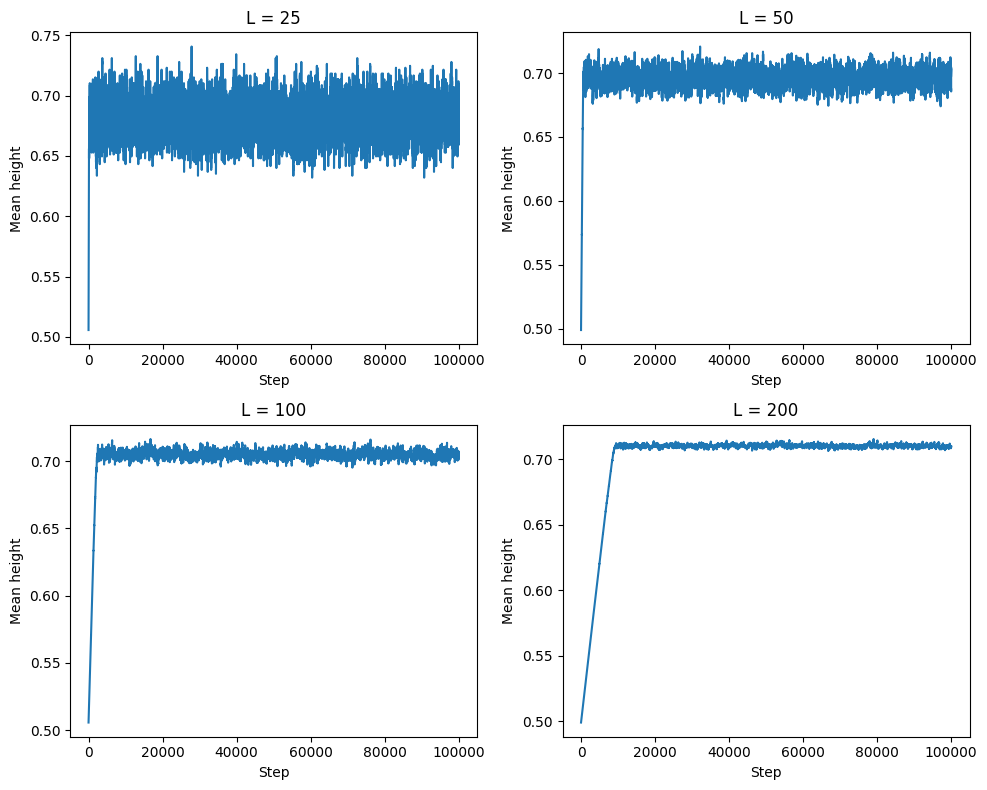

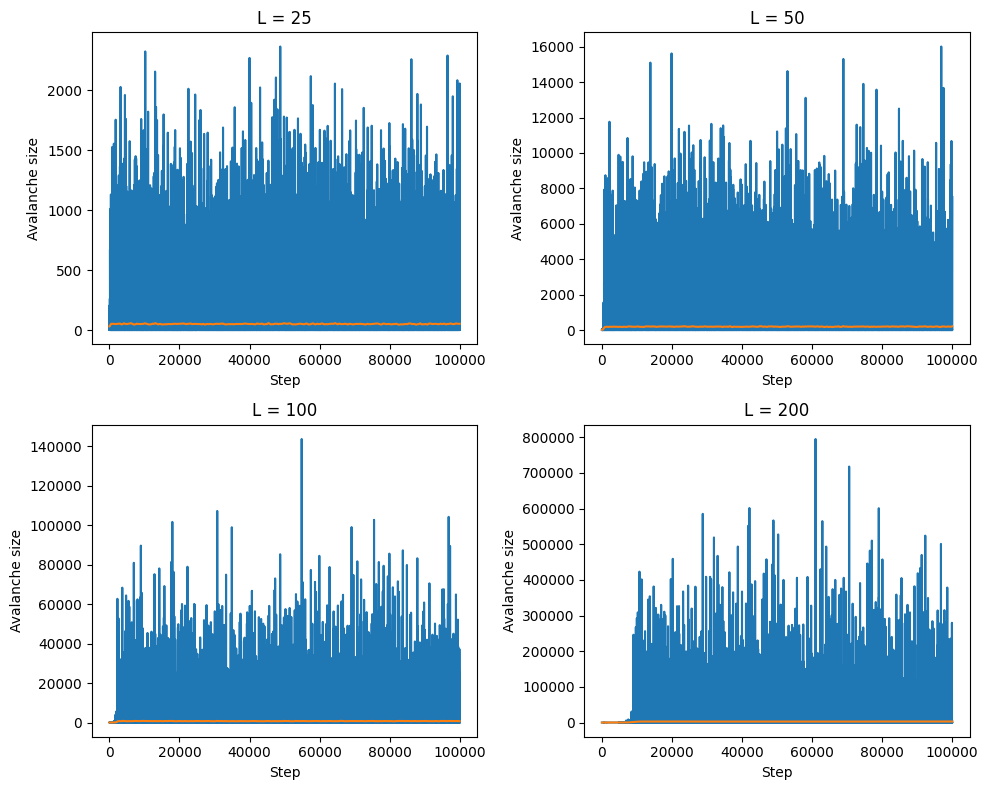

In [9]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(grid_height25)
plt.title("L = 25")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.subplot(2, 2, 2)
plt.plot(grid_height50)
plt.title("L = 50")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.subplot(2, 2, 3)
plt.plot(grid_height100)
plt.title("L = 100")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.subplot(2, 2, 4)
plt.plot(grid_height200)
plt.title("L = 200")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(aval_L25)
mean_aval25 = ski.filters.gaussian(aval_L25, sigma = (200), mode='reflect')
plt.plot(mean_aval25)
plt.title("L = 25")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.subplot(2, 2, 2)
plt.plot(aval_L50)
mean_aval50 = ski.filters.gaussian(aval_L50, sigma = (200), mode='reflect')
plt.plot(mean_aval50)
plt.title("L = 50")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.subplot(2, 2, 3)
plt.plot(aval_L100)
mean_aval100 = ski.filters.gaussian(aval_L100, sigma = (200), mode='reflect')
plt.plot(mean_aval100)
plt.title("L = 100")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.subplot(2, 2, 4)
plt.plot(aval_L200)
mean_aval200 = ski.filters.gaussian(aval_L200, sigma = (1000), mode='reflect')
plt.plot(mean_aval200)
plt.title("L = 200")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.tight_layout()
plt.show()


In [10]:
aval_L25_n = aval_L25[20000:]
aval_L50_n = aval_L50[20000:]
aval_L100_n = aval_L100[20000:]
aval_L200_n = aval_L200[20000:]

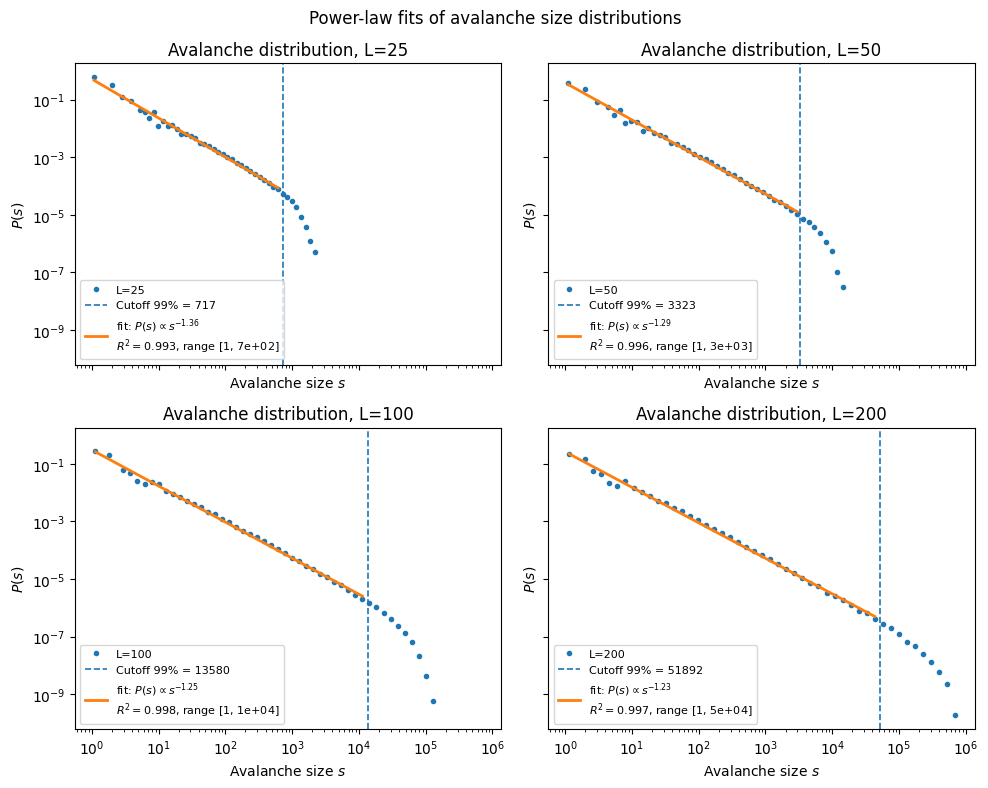

In [67]:
def log_hist(data, bins=50):
    data = np.asarray(data)
    data = data[data > 0]  # safety
    bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), bins)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = np.sqrt(edges[1:] * edges[:-1])
    return centers, hist

def fit_powerlaw_tau(s, P, s_min=None, s_max=None):
    """Return tau, slope, intercept, r2, and x_fit,y_fit for plotting."""
    # keep positive finite values
    m = (s > 0) & (P > 0) & np.isfinite(s) & np.isfinite(P)
    if s_min is not None:
        m &= (s >= s_min)
    if s_max is not None:
        m &= (s <= s_max)
    xs = np.log10(s[m])
    ys = np.log10(P[m])
    if xs.size < 2:
        return np.nan, np.nan, np.nan, np.nan, (np.array([]), np.array([]))
    # ordinary least squares on logs
    slope, intercept = np.polyfit(xs, ys, 1)
    y_pred = slope*xs + intercept
    # R^2
    ss_res = np.sum((ys - y_pred)**2)
    ss_tot = np.sum((ys - np.mean(ys))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    tau = -slope
    # line for plotting (in original scales) over the fit range
    x_line = np.linspace(xs.min(), xs.max(), 100)
    y_line = slope*x_line + intercept
    s_line = 10**x_line
    P_line = 10**y_line
    return tau, slope, intercept, r2, (s_line, P_line)

datasets = {
    25: aval_L25_n,
    50: aval_L50_n,
    100: aval_L100_n,
    200: aval_L200_n,
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (L, aval) in zip(axes, datasets.items()):
    aval = np.asarray(aval)
    aval = aval[aval > 0]

    # histogram
    s, P = log_hist(aval, bins=50)

    # choose a scaling window: exclude the tiniest bins and fit up to 99% cutoff
    s_lo = np.percentile(aval, 1)
    s_hi = np.percentile(aval, 98)

    # fit
    tau, slope, intercept, r2, (sf, Pf) = fit_powerlaw_tau(s, P, s_min=s_lo, s_max=s_hi)

    # plot points
    ax.plot(s, P, '.', label=f"L={L}")
    # cutoff line
    ax.axvline(s_hi, linestyle='--', linewidth=1.2, label=f'Cutoff 99% = {s_hi:.0f}')
    # fitted line
    if sf.size:
        ax.plot(sf, Pf, '-', linewidth=2,
                label=(rf"fit: $P(s)\propto s^{{-{tau:.2f}}}$"
                       f"\n$R^2={r2:.3f}$, range [{s_lo:.1g}, {s_hi:.1g}]"))

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f"Avalanche distribution, L={L}")
    ax.set_xlabel("Avalanche size $s$")
    ax.set_ylabel("$P(s)$")
    ax.legend(loc='lower left', fontsize=8)

fig.suptitle("Power-law fits of avalanche size distributions")
fig.tight_layout()
plt.show()

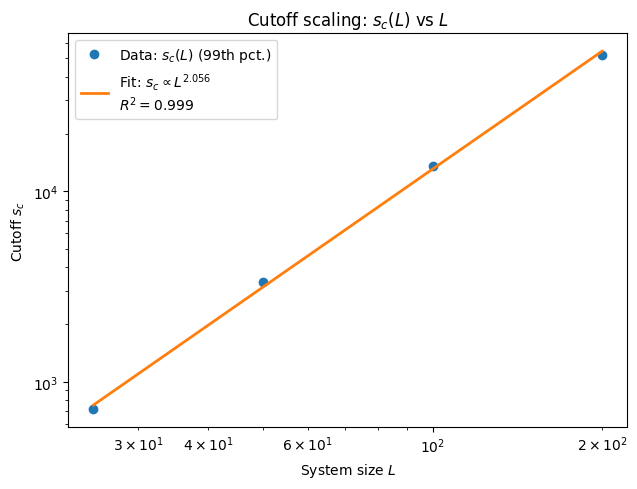

D (slope) = 2.056130, intercept = 0.003531, R^2 = 0.9991


In [68]:
# Compute s_c(L) as the 99th percentile of positive avalanches
Ls = []
s_cs = []
for L, aval in datasets.items():
    aval = np.asarray(aval)
    aval = aval[aval > 0]  # safety
    if aval.size == 0:
        continue
    s_c = np.percentile(aval, 98)
    Ls.append(L)
    s_cs.append(s_c)

Ls = np.array(Ls, dtype=float)
s_cs = np.array(s_cs, dtype=float)

# Fit log10(s_c) = D * log10(L) + b
x = np.log10(Ls)
y = np.log10(s_cs)
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
# R^2 for sanity
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
D = slope

# Line for plotting (smooth)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
L_line = 10**x_line
s_line = 10**y_line

# Plot
plt.figure(figsize=(6.5, 5))
plt.loglog(Ls, s_cs, 'o', label='Data: $s_c(L)$ (99th pct.)')
plt.loglog(L_line, s_line, '-', linewidth=2,
           label=rf'Fit: $s_c \propto L^{{{D:.3f}}}$'
                 + f'\n$R^2={r2:.3f}$')

plt.xlabel(r'System size $L$')
plt.ylabel(r'Cutoff $s_c$')
plt.title(r'Cutoff scaling: $s_c(L)$ vs $L$')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"D (slope) = {D:.6f}, intercept = {intercept:.6f}, R^2 = {r2:.4f}")

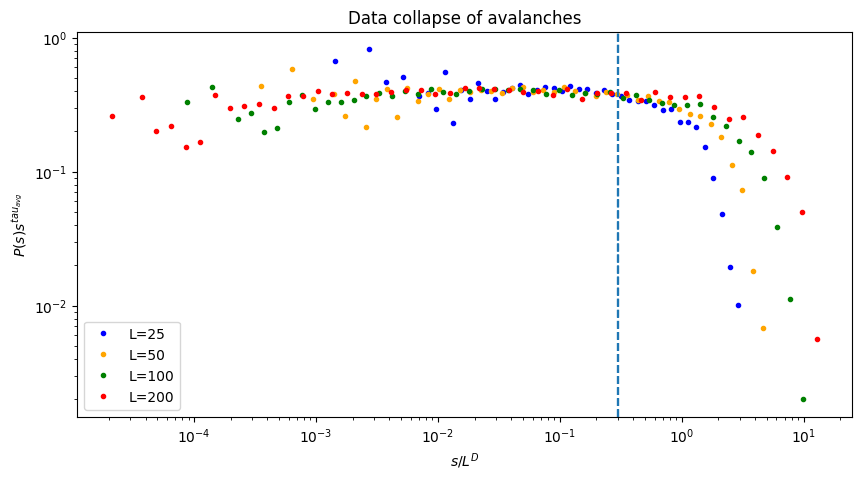

In [70]:
plt.figure(figsize=(10, 5))
def log_hist(data, bins=50):
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), bins)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = np.sqrt(edges[1:] * edges[:-1])
    return centers, hist
k = 0
colors = ["blue", "orange", "green", "red"]
for L, aval in zip([25,50,100,200], [aval_L25_n, aval_L50_n, aval_L100_n, aval_L200_n]):
    mask = aval > 0
    s_cutoff = np.percentile(aval[mask], 99)
    s, P = log_hist(aval[mask], bins = 50)
    
    plt.plot(s/(L**2.056130), P*s**((1.36+1.29+1.25+1.23)/4),'.',color = colors[k], label=f"L={L}")
    plt.axvline(0.3, linestyle='--')
    k+=1

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$s/L^D$")
plt.ylabel(r"$P(s)s^{tau_{avg}}$")
plt.title("Data collapse of avalanches")
plt.legend(loc='lower left')

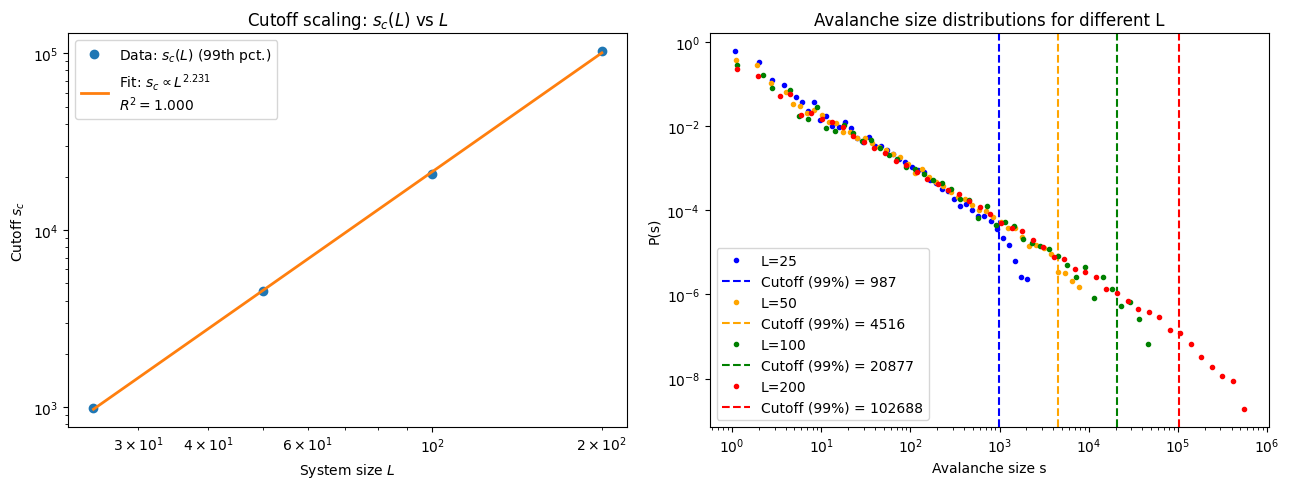

D (slope) = 2.230972, intercept = -0.131032, R^2 = 0.9999


In [41]:
plt.figure(figsize=(13, 5))
def log_hist(data, bins=50):
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), bins)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = np.sqrt(edges[1:] * edges[:-1])
    return centers, hist
k = 0
colors = ["blue", "orange", "green", "red"]
plt.subplot(1,2,2)
for L, aval in zip([25,50,100,200], [aval_L25_n, aval_L50_n, aval_L100_n, aval_L200_n]):
    mask = aval > 0
    s_cutoff = np.percentile(aval[mask], 99)
    s, P = log_hist(aval[mask])
    
    plt.plot(s, P,'.',color = colors[k], label=f"L={L}")
    plt.axvline(s_cutoff, color=colors[k], linestyle='--', linewidth=1.5, label=f'Cutoff (99%) = {s_cutoff:.0f}')
    k+=1

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Avalanche size s")
plt.ylabel("P(s)")
plt.title("Avalanche size distributions for different L")
plt.legend(loc='lower left')

# Compute s_c(L) as the 99th percentile of positive avalanches
Ls = []
s_cs = []
for L, aval in datasets.items():
    aval = np.asarray(aval)
    aval = aval[aval > 0]  # safety
    if aval.size == 0:
        continue
    s_c = np.percentile(aval, 99)
    Ls.append(L)
    s_cs.append(s_c)

Ls = np.array(Ls, dtype=float)
s_cs = np.array(s_cs, dtype=float)

# Fit log10(s_c) = D * log10(L) + b
x = np.log10(Ls)
y = np.log10(s_cs)
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
# R^2 for sanity
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
D = slope

# Line for plotting (smooth)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
L_line = 10**x_line
s_line = 10**y_line

# Plot
plt.subplot(1,2,1)
plt.loglog(Ls, s_cs, 'o', label='Data: $s_c(L)$ (99th pct.)')
plt.loglog(L_line, s_line, '-', linewidth=2,
           label=rf'Fit: $s_c \propto L^{{{D:.3f}}}$'
                 + f'\n$R^2={r2:.3f}$')

plt.xlabel(r'System size $L$')
plt.ylabel(r'Cutoff $s_c$')
plt.title(r'Cutoff scaling: $s_c(L)$ vs $L$')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"D (slope) = {D:.6f}, intercept = {intercept:.6f}, R^2 = {r2:.4f}")


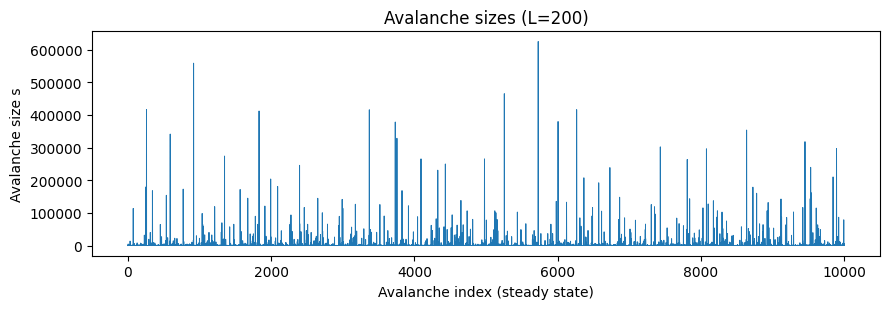

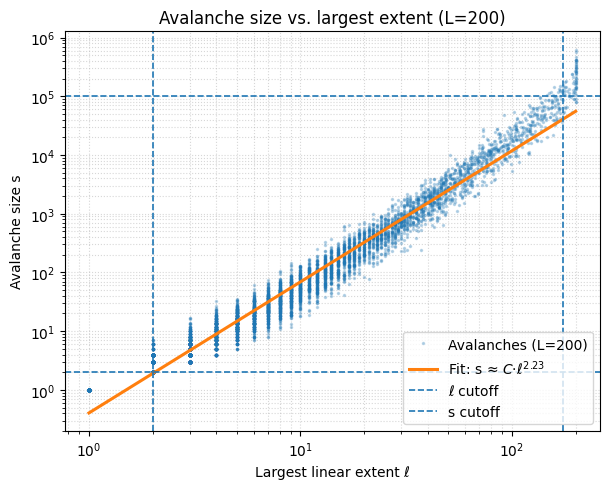

Estimated avalanche dimension D ≈ 2.232
Intercept (log10 C) ≈ -0.393
R^2 ≈ 0.970


In [62]:
# --- 1) Quick glance at the series (optional) ---
plt.figure(figsize=(9,3.2))
plt.plot(aval_L200_n, lw=0.7)
plt.xlabel("Avalanche index (steady state)")
plt.ylabel("Avalanche size s")
plt.title("Avalanche sizes (L=200)")
plt.tight_layout()
plt.show()

# --- 2) s vs largest linear extent ℓ (your scatter) ---
x = np.asarray(L_200[30000:], dtype=float)   # ℓ per avalanche (largest axis-aligned span)
y = np.asarray(aval_L200_n, dtype=float)     # s per avalanche (number of relaxations)

# Basic sanity checks & masks
m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
x, y = x[m], y[m]
assert x.shape == y.shape, "x and y must have the same length."

# Choose a central window to avoid tiny-ℓ discreteness and ultra-rare huge events
logx = np.log10(x)
logy = np.log10(y)
lo, hi = np.percentile(logx, [10, 99])   # you can tweak (e.g., 15–85)
sel = (logx >= lo) & (logx <= hi)

# Fit in log–log space using a robust linear regression
res = linregress(logx[sel], logy[sel])
slope = res.slope          # this is D in s ~ ℓ^D
intercept = res.intercept
r2 = res.rvalue**2

# Build a smooth fitted line over the displayed x-range
xx = np.logspace(logx.min(), logx.max(), 200)
yy = 10**(intercept + slope * np.log10(xx))

# --- 3) Pretty log–log plot with fit overlay ---
plt.figure(figsize=(6.2,5.0))
plt.loglog(x, y, '.', ms=3, alpha=0.25, label="Avalanches (L=200)")
plt.loglog(xx, yy, '-', lw=2.2, label=r"Fit: s ≈ $C·ℓ^{2.23}$")

# Optional: show the cutoff (e.g., 99th percentile of size)
s_cut = np.percentile(y, 99)
plt.axvline(np.percentile(x, 99), ls='--', lw=1.2, label = "ℓ cutoff")  # ℓ cutoff (optional)
plt.axhline(s_cut, ls='--', lw=1.2, label = "s cutoff")                 # s cutoff (optional)

plt.axvline(np.percentile(x, 10), ls='--', lw=1.2)  # ℓ cutoff (optional)
plt.axhline(np.percentile(y, 10), ls='--', lw=1.2)                 # s cutoff (optional)

plt.xlabel("Largest linear extent ℓ")
plt.ylabel("Avalanche size s")
plt.title("Avalanche size vs. largest extent (L=200)")
plt.legend(loc='lower right')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Estimated avalanche dimension D ≈ {slope:.3f}")
print(f"Intercept (log10 C) ≈ {intercept:.3f}")
print(f"R^2 ≈ {r2:.3f}")

In [65]:
print(np.array(range(10)))

[0 1 2 3 4 5 6 7 8 9]


In [69]:
def boundary_coords(N):
    top    = [(0, j) for j in range(N)]
    bottom = [(N-1, j) for j in range(N)]
    left   = [(i, 0) for i in range(1, N-1)]
    right  = [(i, N-1) for i in range(1, N-1)]
    return np.array(top + bottom + left + right, dtype=int)

def SOC_new(n, N):
    sandbox_hist = np.zeros((n,N,N))
    #sandbox = np.random.randint(0,2,size=(N,N))
    sandbox = np.zeros((N,N))
    count = np.zeros(n)
    grid_height = np.zeros(n)
    L = np.zeros(n)
    B = boundary_coords(N)

    for _ in range(n):
        if _%round(n/4) == 0:
            print(f"{_/n}% Done")
        i, j = B[np.random.randint(len(B))]
        min_x = i
        max_x = i
        min_y = j
        max_y = j

        sandbox[i,j] += 1
        mask = sandbox >= 2
        while mask.any():
            # sites that will topple this iteration (in current coordinates)
            xs, ys = np.where(mask)

            if xs.size:

                # update total span bounding box
                min_x = min(min_x, int(xs.min()))
                max_x = max(max_x, int(xs.max()))
                min_y = min(min_y, int(ys.min()))
                max_y = max(max_y, int(ys.max()))

            sandbox, mask, topples = s_topple_once(sandbox, mask)
            count[_] += topples
        L_x = max_x-min_x+1
        L_y = max_y-min_y+1
        L[_] = max(L_x, L_y)
        grid_height[_] = np.mean(sandbox)
        sandbox_hist[_] = sandbox
    return sandbox_hist, count, grid_height, L

In [77]:
grids200_b, aval_L200_b, grid_height200_b, L_200_b = SOC_new(500000,100)

0.0% Done
0.25% Done
0.5% Done
0.75% Done


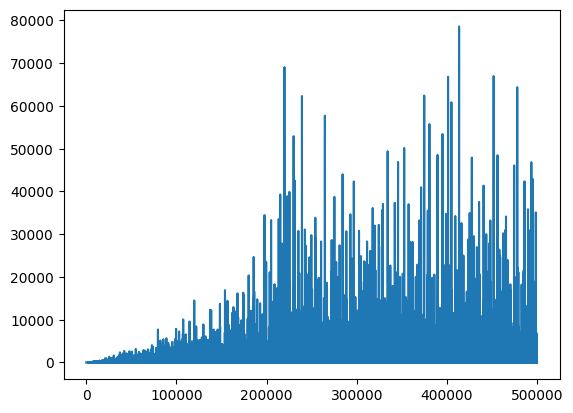

In [78]:
plt.plot(aval_L200_b)

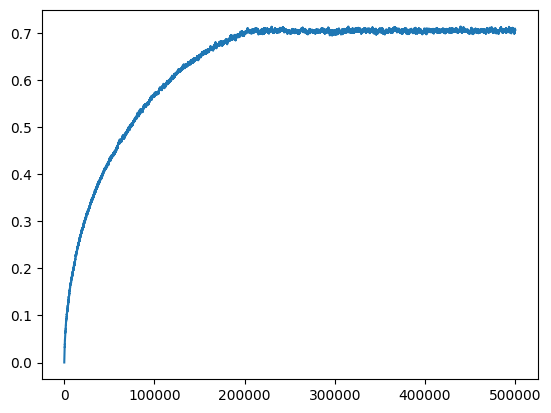

In [79]:
plt.plot(grid_height200_b)

In [81]:
aval_L100_new = aval_L200_b[250000:]

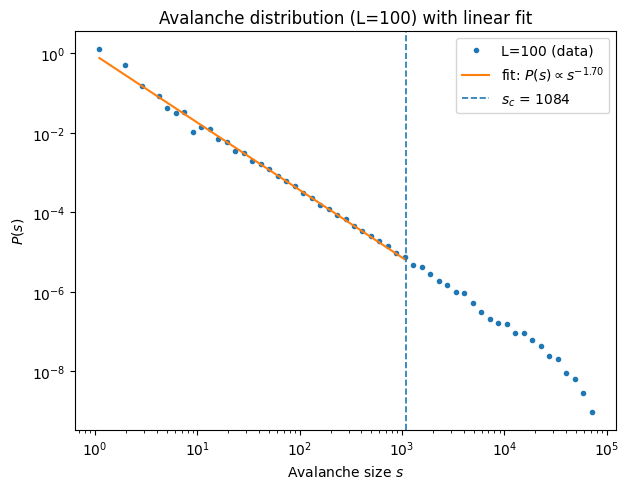

tau (regular linear fit) = 1.6953


In [95]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Log-binned histogram
def log_hist(data, bins=60):
    data = np.asarray(data)
    data = data[data > 0]
    edges = np.logspace(np.log10(data.min()), np.log10(data.max()), bins)
    hist, edges = np.histogram(data, bins=edges, density=True)
    centers = np.sqrt(edges[1:] * edges[:-1])
    return centers, hist

# ----- single dataset -----
aval = np.asarray(aval_L100_new)
aval = aval[aval > 0]

s, P = log_hist(aval, bins=60)

# 2) Plain linear fit on logs
m = (s > 0) & (P > 0)
s_lo, s_hi = np.percentile(aval, [10, 99])
m = m & (s >= s_lo) & (s <= s_hi)
x = np.log10(s[m])
y = np.log10(P[m])

slope, intercept = np.polyfit(x, y, 1)     # linear fit: y = slope*x + intercept
tau = -slope                                # P(s) ~ s^{-tau}

# 3) Plot
plt.figure(figsize=(6.4, 5))
plt.plot(s, P, '.', label='L=100 (data)')
# fitted line in original (non-log) axes
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
plt.plot(10**x_line, 10**y_line, '-', label=rf'fit: $P(s)\propto s^{{-{tau:.2f}}}$')
plt.axvline(s_hi, ls='--', lw=1.2, label = f"$s_c$ = {s_hi:.0f}")

plt.xscale('log'); plt.yscale('log')
plt.xlabel('Avalanche size $s$')
plt.ylabel('$P(s)$')
plt.title('Avalanche distribution (L=100) with linear fit')
plt.legend()
plt.tight_layout()
plt.show()

print(f"tau (regular linear fit) = {tau:.4f}")
